In [1]:
import yaml
import numpy as np
import polars as pl
import polars.selectors as cs
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Get gene trait associations
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results/regenie_127phenotypes_lofteeHC_mac20_EUR.parquet -o /home/dnanexus/data_dir/
# !dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results/loftee_mac20_associations_bh_corrected.parquet -o /home/dnanexus/data_dir/

!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results/regenie_127phenotypes_mac20_lofteeHC_EUR_correlations.parquet -o /home/dnanexus/data_dir/

gene_trait_df = (
    pl.read_parquet('/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR.parquet')
    .filter(pl.col('pval_fdr')<=0.05)
    .select(['region', 'phenotype', 'pval_fdr'])
)

loftee_corrs = (
    pl.read_parquet('/home/dnanexus/data_dir/regenie_127phenotypes_mac20_lofteeHC_EUR_correlations.parquet')
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

gene_trait_df = (
    gene_trait_df
    .join(loftee_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    .sort('loftee_corr_abs', descending=True)
    .unique(subset=["region"], keep="first", maintain_order=True)
)
gene_trait_df

Error: path
"/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR.parquet"
already exists but -f/--overwrite was not set
Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_mac20_lofteeHC_EUR_
correlations.parquet" already exists but -f/--overwrite was not set


region,phenotype,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir
str,str,f64,f64,f64,f64
"""ENSG00000244734""","""mean_corpuscular_haemoglobin_i…",5.8426e-107,-0.414609,0.414609,-1.0
"""ENSG00000188536""","""mean_corpuscular_haemoglobin_i…",4.2593e-22,-0.366514,0.366514,-1.0
"""ENSG00000101439""","""cystatin_c_int""",9.0570e-172,-0.364046,0.364046,-1.0
"""ENSG00000167941""","""heel_bone_mineral_density_bmd_…",0.004143,0.309961,0.309961,1.0
"""ENSG00000149948""","""standing_height_int""",0.035047,-0.302164,0.302164,-1.0
…,…,…,…,…,…
"""ENSG00000162992""","""glycated_haemoglobin_hba1c_int""",0.000525,0.004895,0.004895,1.0
"""ENSG00000134030""","""leg_fat_percentage_right_int""",0.028495,0.003606,0.003606,1.0
"""ENSG00000114796""","""position_of_pulse_wave_notch_i…",0.03963,-0.003476,0.003476,-1.0


In [3]:
# Configuration and paths
mac = 20
pheno_list_type = None

# Load phenotype configuration
pheno_config_path = "/home/dnanexus/ukbgym/phenotype_config.yaml"
with open(pheno_config_path) as f:
    pheno_config = yaml.safe_load(f)

if pheno_list_type is not None:
    pheno_list = pheno_config[pheno_list_type]

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_odds_categories.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""genomic_region""","""mane_cds""","""#E31A1C""","""MANE CDS""",1
"""genomic_region""","""non_mane_cds""","""#FB9A99""","""Other CDS""",1
"""genomic_region""","""mane_exonic""","""#33A02C""","""MANE Exon""",1
"""genomic_region""","""non_mane_exonic""","""#B2DF8A""","""Other Exon""",1
"""plof_consequences""","""consequence_frameshift_variant""","""#E31A1C""","""VEP Frameshift""",1
…,…,…,…,…
"""encode_enhancer""","""encode_ca_ctcf""","""#4DAF4A""","""Accessible Region with CTCF Bi…",1
"""encode_enhancer""","""encode_ca""","""#377EB8""","""Chromatin Accessible""",1
"""encode_enhancer""","""encode_ca_tf""","""#1D6498""","""Accessible Region with TF Bind…",1


In [ ]:
RAP_ANNO_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated"
LOCAL_ANNO_DIR = "/home/dnanexus/data_dir"

# ANNO_FILE = "annotations_fillna_ukbgym.parquet"
ANNO_FILE = "annotations_fillna_ukbgym_with_mane.parquet"

!dx download {RAP_ANNO_DIR}/{ANNO_FILE} -o {LOCAL_ANNO_DIR}/{ANNO_FILE}
anno = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")

min_range = -500
max_range = +500

anno = (
    anno
    .with_columns(
        encode_eh_pr = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_pls', 'encode_pels', 'encode_dels']),
        encode_all_tf = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_tf', 'encode_ca-tf']),
        encode_annotated = pl.col('not_annotated_in_encode') == False,
        canonical_splice_variant = (pl.col('consequence_splice_acceptor_variant') == True) | (pl.col('consequence_splice_donor_variant') == True)
    )
    .filter(
        # Choose CDS
        # (pl.col('vep_cds_relaxed')==True) &

        # Choose non CDS only
        # UPDATE WITH NEW VEP MANE ANNOS
        # ((pl.col('vep_cds_relaxed')==False) & (pl.col('mane_cds')==False) & (pl.col('non_mane_cds')==False)) &

        # Choose VEP consequence
        # (pl.col('consequence_missense_variant') == True) &
        # (pl.any_horizontal(cs.contains("consequence_splice") == True)) &
        # (pl.col('consequence_upstream_gene_variant') == True) &
        # (pl.col('consequence_downstream_gene_variant') == True) &

        # Core promoter
        (pl.col('promoterai_is_na') == False) &

        # Choose Introns with/without alternate CDS
        # (pl.col('consequence_intron_variant') == True) &
        # ((pl.col('consequence_intron_variant') == True) & (pl.col('non_mane_cds')==False)) &

        # ((pl.col('dist_to_tss') < max_range) & (pl.col('dist_to_tss') > min_range)) &
        
        # Choose Gene Body
        # ((pl.col('consequence_upstream_gene_variant') == False) & (pl.col('consequence_downstream_gene_variant') == False)) &

        # Choose regulatory region
        # (pl.col('not_in_encode') == False) &
        # (pl.col('encode_eh_pr') == True) &
        # (pl.col('encode_all_tf') == True) &
        
        # Filter to gene regions of interest
        (pl.col('region').is_in(gene_trait_df['region'].unique()))
    )
    
    .with_columns(
        loftee_disorder = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'mobi_curated_disorder_priority']),
        loftee_lip = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'mobi_lip_full']),
        loftee_ted = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'ted_domain']),
        loftee_low_complexity = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'low_complexity_domain']),
    )
    .with_columns(
        indel_length = (pl.col('ref').str.len_chars() - pl.col('alt').str.len_chars()).abs(),
        insertion = pl.when(pl.col('ref').str.len_chars() < pl.col('alt').str.len_chars()).then(True).otherwise(False),
        deletion = pl.when(pl.col('ref').str.len_chars() > pl.col('alt').str.len_chars()).then(True).otherwise(False),
    )
    .with_columns(
        # --- Indel CDS categories ---
        deletion_x3bp = pl.when(pl.col('deletion') & (pl.col('indel_length') %3 == 0)).then(True).otherwise(False),
        deletion_not_x3bp = pl.when(pl.col('deletion') & (pl.col('indel_length') %3 != 0)).then(True).otherwise(False),
        insertion_x3bp = pl.when(pl.col('insertion') & (pl.col('indel_length') %3 == 0)).then(True).otherwise(False),
        insertion_not_x3bp = pl.when(pl.col('insertion') & (pl.col('indel_length') %3 != 0)).then(True).otherwise(False),
    )
    .with_columns(
        # --- ENCODE indels ---
        encode_deletion = pl.when(pl.col('deletion') & (pl.col('encode_annotated')==True)).then(True).otherwise(False),
        encode_insertion = pl.when(pl.col('insertion') & (pl.col('encode_annotated')==True)).then(True).otherwise(False),
        encode_snp = pl.when((pl.col('encode_annotated')==True) & (pl.col('deletion')==False) & (pl.col('insertion')==False)).then(True).otherwise(False),

        # --- ENCODE deletions ---
        encode_deletion_gt2bp = pl.when((pl.col('indel_length') >= 2) & (pl.col('encode_annotated')==True)).then(True).otherwise(False) & pl.col('deletion'),
        encode_deletion_gt5bp = pl.when((pl.col('indel_length') >= 5) & (pl.col('encode_annotated')==True)).then(True).otherwise(False) & pl.col('deletion'),
    )
)


# selected_categories = ['genomic_region'] # genomic_region
# selected_categories = ['plof_consequences'] # plof consequences
# selected_categories = ['loftee_hc', 'loftee_lc'] # loftee consequences
# selected_categories = ['plof', 'missense'] # CDS
# selected_categories = ['protein_domains'] # Protein Domains
# selected_categories = ['loftee_protein_domains'] # LOFTEE Protein Domains
# selected_categories = ['splicing'] # Splicing
# selected_categories = ['indel_cds'] # CDS indels
# selected_categories = ['indel_categories'] # indel length
# selected_categories = ['encode_boolean'] # encode
# selected_categories = ['encode_indels'] # encode indels
# selected_categories = ['encode_deletions'] # encode deletions
# selected_categories = ['encode_custom'] # encode custom regions
# selected_categories = ['encode_enhancer'] # encode regions
selected_categories = ['5utr_annotator', 'encode_boolean'] # 5utr

selected_annos = anno_config_df.filter(
    pl.col('category').is_in(selected_categories)
)['annotation'].to_list()

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]
selected_annos = list(set(selected_annos).intersection(set(existing_annos)))
fillna_cols = [c+'_is_na' for c in selected_annos]

anno = (
    anno
    .select(
        set(['id', 'region']).union(set(selected_annos))
    )
    .collect(engine='streaming')
)


anno

Error: path
"/home/dnanexus/data_dir/annotations_fillna_ukbgym_with_mane.parquet" already
exists but -f/--overwrite was not set


/tmp/ipykernel_559994/1151983496.py:86: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
/tmp/ipykernel_559994/1151983496.py:93: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


dist_to_tss,loftee_hc,id,five_prime_utr_variant_consequence_ustop_gained,consequence_missense_variant,mobi_curated_disorder_priority,low_complexity_domain,loftee_low_complexity,not_annotated_in_encode,encode_insertion,mane_exonic,non_mane_exonic,encode_snp,deletion_x3bp,consequence_splice_acceptor_variant,non_mane_cds,five_prime_utr_variant_consequence_uaug_gained,ted_domain,deletion,mane_cds,consequence_frameshift_variant,encode_annotated,encode_pels,loftee_lc,gene_name,encode_pls,consequence_stop_gained,five_prime_utr_variant_consequence_uaug_lost,strand,mobi_lip_full,consequence_splice_donor_variant,deletion_not_x3bp,loftee_ted,encode_all_tf,tss,canonical_splice_variant,insertion_x3bp,encode_tf,encode_deletion,consequence_stop_lost,insertion_not_x3bp,region,insertion,loftee_disorder,encode_deletion_gt2bp,encode_eh_pr,encode_deletion_gt5bp,five_prime_utr_variant_consequence_ustop_lost,consequence_start_lost,five_prime_utr_variant_consequence_uframeshift,loftee_lip,encode_ca,gene_length,encode_dels
i64,i8,str,u8,i8,bool,bool,bool,bool,bool,bool,bool,bool,bool,i8,bool,u8,bool,bool,bool,i8,bool,bool,i8,str,bool,i8,u8,cat,bool,i8,bool,bool,bool,i64,bool,bool,bool,bool,i8,bool,str,bool,bool,bool,bool,bool,u8,i8,u8,bool,bool,i64,bool
418969,0,"""chr6:152218832:A:T""",0,0,false,false,false,true,false,false,false,false,false,0,false,0,false,false,false,0,false,false,0,"""SYNE1""",false,0,0,"""-""",false,0,false,false,false,152637801,false,false,false,false,0,false,"""ENSG00000131018""",false,false,false,false,false,0,0,0,false,false,516116,false
493610,0,"""chr21:40353548:C:T""",0,1,false,false,false,true,false,true,false,false,false,0,false,0,true,false,true,0,false,false,0,"""DSCAM""",false,0,0,"""-""",false,0,false,false,false,40847158,false,false,false,false,0,false,"""ENSG00000171587""",false,false,false,false,false,0,0,0,false,false,836161,false
128592,0,"""chr2:178702210:C:G""",0,1,true,false,false,true,false,true,false,false,false,0,false,0,false,false,true,0,false,false,0,"""TTN""",false,0,0,"""-""",true,0,false,false,false,178830802,false,false,false,false,0,false,"""ENSG00000155657""",false,false,false,false,false,0,0,0,false,false,304815,false
3148,0,"""chr17:7408021:G:T""",0,0,false,false,false,false,false,true,false,true,false,0,false,0,false,false,false,0,true,true,0,"""NLGN2""",false,0,0,"""+""",false,0,false,false,false,7404873,false,false,false,false,0,false,"""ENSG00000169992""",false,false,false,true,false,0,0,0,false,false,14988,false
494,0,"""chr10:63521894:G:A""",0,0,false,false,false,false,false,false,false,true,false,0,false,0,false,false,false,0,true,true,0,"""REEP3""",false,0,0,"""+""",false,0,false,false,false,63521400,false,false,false,false,0,false,"""ENSG00000165476""",false,false,false,true,false,0,0,0,false,false,103729,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
49,0,"""chr17:35809530:C:G""",0,0,false,false,false,false,false,true,false,true,false,0,false,0,false,false,false,0,true,false,0,"""TAF15""",true,0,0,"""+""",false,0,false,false,false,35809481,false,false,false,false,0,false,"""ENSG00000270647""",false,false,false,true,false,0,0,0,false,false,55135,false
26269,0,"""chr16:18900139:T:C""",0,0,false,false,false,true,false,false,false,false,false,0,false,0,false,false,false,0,false,false,0,"""SMG1""",false,0,0,"""-""",false,0,false,false,false,18926408,false,false,false,false,0,false,"""ENSG00000157106""",false,false,false,false,false,0,0,0,false,false,121550,false
257,0,"""chr20:47356632:A:C""",0,0,false,false,false,false,false,false,false,true,false,0,false,0,false,false,false,0,true,false,0,"""ZMYND8""",true,0,0,"""-""",false,0,false,false,false,47356889,false,false,false,false,0,false,"""ENSG00000101040""",false,false,false,true,false,0,0,0,false,false,147677,false


In [ ]:
# Handle fillna annotations
anno_fillna = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")
fillna_cols = set([c+'_is_na' for c in selected_annos]).intersection(set(anno_fillna.collect_schema().names()))

anno_fillna_melted = (
    anno_fillna
    .filter(pl.col('region').is_in(gene_trait_df['region'].unique()))
    .select(['id', 'region', 'gene_name'] + list(fillna_cols))
    .join(
        anno.select(['id', 'region', 'gene_name']).lazy(), 
        on=['id', 'region', 'gene_name'], 
        how='semi'
    )
    .unpivot(
        index=["id", "region", "gene_name"],
        on=list(fillna_cols),
        variable_name="annotation",
        value_name="annotation_is_na"
    )
    .filter(
        pl.col('annotation_is_na') == False
    )
    .with_columns(
        annotation = pl.col('annotation').str.replace('_is_na$', '')
    )
    # .collect(engine='streaming')
)

melted_anno = (
    anno

    .unpivot(
        index=["id", "region", "gene_name"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )

    # Merge with annotation configuration to get direction and filter
    .join(
        anno_config_df.select(["annotation", "category", "annotation_dir"]),
        on="annotation",
        how="left"
    )
    .filter(pl.col('category').is_in(selected_categories))
    .unique()

    .with_columns(
        # annotation_score_dircor = pl.col('annotation_score') * pl.col("annotation_dir")
        annotation_score_dircor = (
            pl.when(pl.col("annotation_dir")!=1)
            .then((pl.col('annotation_score')-1).abs())
            .otherwise(pl.col('annotation_score'))
        )
    )
    
    # Keep variants that don't have fillna annotation
    .join(
        anno_fillna_melted,
        on=['id', 'region', 'annotation'],
        how='anti'
    )
    # .drop_nulls()
    # .filter(pl.col('annotation_score').is_not_null())
)

melted_anno

id,region,gene_name,annotation,annotation_score,category,annotation_dir,annotation_score_dircor
str,str,str,str,f32,str,i8,f32
"""chr4:38045941:C:G""","""ENSG00000065882""","""TBC1D1""","""five_prime_utr_variant_consequ…",0.0,"""5utr_annotator""",1,0.0
"""chr12:460161:C:G""","""ENSG00000139044""","""B4GALNT3""","""encode_annotated""",0.0,"""encode_boolean""",1,0.0
"""chr4:81153260:C:G""","""ENSG00000138669""","""PRKG2""","""five_prime_utr_variant_consequ…",0.0,"""5utr_annotator""",1,0.0
"""chr17:19237878:G:C""","""ENSG00000072134""","""EPN2""","""five_prime_utr_variant_consequ…",0.0,"""5utr_annotator""",1,0.0
"""chr16:87492706:C:T""","""ENSG00000140948""","""ZCCHC14""","""five_prime_utr_variant_consequ…",0.0,"""5utr_annotator""",1,0.0
…,…,…,…,…,…,…,…
"""chr2:27217223:G:C""","""ENSG00000084774""","""CAD""","""not_annotated_in_encode""",0.0,"""encode_boolean""",1,0.0
"""chr13:21459286:G:A""","""ENSG00000180776""","""ZDHHC20""","""five_prime_utr_variant_consequ…",0.0,"""5utr_annotator""",1,0.0
"""chr5:179907677:A:C""","""ENSG00000197226""","""TBC1D9B""","""encode_annotated""",1.0,"""encode_boolean""",1,1.0


In [7]:
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var/loftee_mac20_quant_pheno_assocs_EURunrelated_appv_percentiles.parquet -o /home/dnanexus/data_dir/loftee_mac20_quant_pheno_assocs_EURunrelated_appv_percentiles.parquet

appv = pl.scan_parquet("/home/dnanexus/data_dir/loftee_mac20_quant_pheno_assocs_EURunrelated_appv_percentiles.parquet")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = (
    appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value_ptile', 'n_individuals']
    )
)
# unique_phenotypes = appv.select('phenotype').unique().collect(engine='streaming').to_series()

Error: path "/home/dnanexus/data_dir/loftee_mac20_quant_pheno_assocs_EURunrela
ted_appv_percentiles.parquet" already exists but -f/--overwrite was not set


In [13]:
n_steps = 101
or_threshold_pheno_left = 1
or_threshold_pheno_right = 1e-4

cutoffs_list = 1 - np.logspace(
    np.log10(or_threshold_pheno_left),
    np.log10(or_threshold_pheno_right),
    num=n_steps
)

pheno_cutoffs_lazy = pl.LazyFrame({"pheno_cutoff": cutoffs_list.tolist()})

pheno_cutoffs_lazy.collect()

pheno_cutoff
f64
0.0
0.087989
0.168236
0.241422
0.308169
…
0.999855
0.999868
0.99988


In [14]:
# --- 1. Lazily prepare the filter keys ---
region_keys = gene_trait_df.lazy().select(pl.col('region').unique())
anno_ids_lazy = melted_anno.lazy().join(
    region_keys, on='region', how='semi'
).select(pl.col('id').unique())

# --- Build main query (same as before, but stop before group_by) ---
gp_lazy = (
    appv
    # Select required variants
    .join(
        anno_ids_lazy, 
        on="id", 
        how="semi"
    )
    # Merge annotation scores
    .join(
        melted_anno.lazy(),
        on="id", 
        how="inner"
    )
    # Merge with gene_trait_df
    .join(
        gene_trait_df.lazy(), 
        on=["region", "phenotype"], 
        how="inner"
    )
    .with_columns(
        mean_pheno_value_dircor_ptile = pl.when(pl.col('loftee_corr_dir') == -1) # To get 1/100, 1/1000, etc.
            .then(1 - pl.col('mean_pheno_value_ptile'))
            .otherwise(pl.col('mean_pheno_value_ptile')),
    )
    
    # Cross join with cutoffs and compute odds ratios
    .join(
        pheno_cutoffs_lazy, 
        how="cross"
    )
    .group_by(["annotation", "region", "gene_name", "phenotype", "pheno_cutoff"])
    .agg(
        n_dis_above_cutoff = (
            (pl.col("annotation_score_dircor") == 1) & 
            (pl.col("mean_pheno_value_dircor_ptile") >= pl.col("pheno_cutoff"))
        ).sum(),
        n_notdis_above_cutoff = (
            (pl.col("annotation_score_dircor") == 1) & 
            (pl.col("mean_pheno_value_dircor_ptile") < pl.col("pheno_cutoff"))
        ).sum(),
        n_dis_below_cutoff = (
            (pl.col("annotation_score_dircor") == 0) & 
            (pl.col("mean_pheno_value_dircor_ptile") >= pl.col("pheno_cutoff"))
        ).sum(),
        n_notdis_below_cutoff = (
            (pl.col("annotation_score_dircor") == 0) & 
            (pl.col("mean_pheno_value_dircor_ptile") < pl.col("pheno_cutoff"))
        ).sum()
    )
    .with_columns(
        odds_ratio = (pl.col("n_dis_above_cutoff") / pl.col("n_notdis_above_cutoff")) / (pl.col("n_dis_below_cutoff") / pl.col("n_notdis_below_cutoff"))
    )
)

# Execute
print("Executing with odds ratios...")
or_df = gp_lazy.collect(engine='streaming').sort('pheno_cutoff')

or_df

Executing with odds ratios...


annotation,region,gene_name,phenotype,pheno_cutoff,n_dis_above_cutoff,n_notdis_above_cutoff,n_dis_below_cutoff,n_notdis_below_cutoff,odds_ratio
str,str,str,str,f64,u64,u64,u64,u64,f64
"""five_prime_utr_variant_consequ…","""ENSG00000103196""","""CRISPLD2""","""standing_height_int""",0.0,0,0,933,0,NaN
"""five_prime_utr_variant_consequ…","""ENSG00000056586""","""RC3H2""","""fluid_intelligence_score_int""",0.0,2,0,621,0,NaN
"""encode_annotated""","""ENSG00000111452""","""ADGRD1""","""forced_vital_capacity_fvc_int""",0.0,485,0,278,0,NaN
"""five_prime_utr_variant_consequ…","""ENSG00000117400""","""MPL""","""platelet_crit_int""",0.0,0,0,428,0,NaN
"""not_annotated_in_encode""","""ENSG00000167165""","""UGT1A6""","""total_bilirubin_int""",0.0,815,0,1700,0,NaN
…,…,…,…,…,…,…,…,…,…
"""five_prime_utr_variant_consequ…","""ENSG00000112200""","""ZNF451""","""glucose_int""",0.9999,0,0,0,466,NaN
"""five_prime_utr_variant_consequ…","""ENSG00000105707""","""HPN""","""albumin_int""",0.9999,0,2,3,466,0.0
"""five_prime_utr_variant_consequ…","""ENSG00000090534""","""THPO""","""platelet_crit_int""",0.9999,0,0,10,752,NaN


In [15]:
# or_df = pl.read_parquet(f'/home/dnanexus/data_dir/results/odds_ratio_all_vars_{or_threshold_pheno}_wgs_EUR_genebass1e6_maf1e3.parquet')

print('unique percentile cutoffs:', or_df['pheno_cutoff'].n_unique())

plt_df = (
    or_df
    .drop_nans()
    .filter(pl.col("odds_ratio").is_finite())
    .with_columns(
        n_gene_phenos = pl.len().over(['pheno_cutoff', 'annotation']),
        pheno_cutoff_inv = 1 - pl.col('pheno_cutoff'),
    )
    .with_columns(
        neg_log_pheno_cutoff_inv = -np.log10(pl.col('pheno_cutoff_inv')),
        med_odds_ratio = pl.col('odds_ratio').median().over(['pheno_cutoff_inv', 'annotation']),
        avg_odds_ratio = pl.col('odds_ratio').mean().over(['pheno_cutoff_inv', 'annotation']),
        se_odds_ratio = pl.col('odds_ratio').std().over(['pheno_cutoff_inv', 'annotation'])/(pl.col('n_gene_phenos').sqrt()),
    )
    .with_columns(
        std_ci_upper = pl.col('avg_odds_ratio') + 1.96 * (pl.col('se_odds_ratio')),
        std_ci_lower = pl.col('avg_odds_ratio') - 1.96 * (pl.col('se_odds_ratio')),
    )
    .select(['annotation', 'neg_log_pheno_cutoff_inv', 'pheno_cutoff', 'pheno_cutoff_inv', 'n_gene_phenos', 'med_odds_ratio', 'avg_odds_ratio', 'se_odds_ratio', 'std_ci_upper', 'std_ci_lower'])
    .unique()
    
    # join plotting info
    .join(
        anno_config_df.select(['annotation', 'color', 'label']).unique(),
        on='annotation',
        how='left'
    )
    .sort('pheno_cutoff_inv')

    # Remove data points without ci or with or=0
    .filter(
        (pl.col('std_ci_upper').is_not_null()) &
        (pl.col('std_ci_lower').is_not_null()) &
        (pl.col('n_gene_phenos') >= 20) &
        (pl.col('avg_odds_ratio') > 0) &
        (pl.col('std_ci_lower') > 0)
    )
)

plt_df

unique percentile cutoffs: 101


annotation,neg_log_pheno_cutoff_inv,pheno_cutoff,pheno_cutoff_inv,n_gene_phenos,med_odds_ratio,avg_odds_ratio,se_odds_ratio,std_ci_upper,std_ci_lower,color,label
str,f64,f64,f64,u64,f64,f64,f64,f64,f64,str,str
"""encode_annotated""",4.0,0.9999,0.0001,225,0.806122,0.93193,0.062033,1.053515,0.810346,"""peru""","""ENCODE annotated region"""
"""five_prime_utr_variant_consequ…",4.0,0.9999,0.0001,223,0.0,1.554297,0.735362,2.995607,0.112987,"""#FFD700""","""5UTR Start Gain"""
"""not_annotated_in_encode""",4.0,0.9999,0.0001,277,0.75,1.096657,0.090352,1.273747,0.919567,"""black""","""Region not annotated in ENCODE"""
"""not_annotated_in_encode""",3.96,0.99989,0.00011,288,0.786694,1.099991,0.08729,1.271079,0.928902,"""black""","""Region not annotated in ENCODE"""
"""encode_annotated""",3.96,0.99989,0.00011,226,0.809478,0.958223,0.064936,1.085497,0.830948,"""peru""","""ENCODE annotated region"""
…,…,…,…,…,…,…,…,…,…,…,…
"""encode_annotated""",0.08,0.168236,0.831764,23,0.970428,0.985667,0.047664,1.079089,0.892245,"""peru""","""ENCODE annotated region"""
"""encode_annotated""",0.04,0.087989,0.912011,71,1.032931,1.09128,0.03853,1.166798,1.015762,"""peru""","""ENCODE annotated region"""
"""five_prime_utr_variant_consequ…",0.04,0.087989,0.912011,27,0.0,0.987933,0.404802,1.781344,0.194522,"""#DAA520""","""5UTR Start Lost"""


/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/plotnine/geoms/annotation_logticks.py:97: PlotnineWarning: annotation_logticks for x-axis which does not have a log scale. The logticks may not make sense.


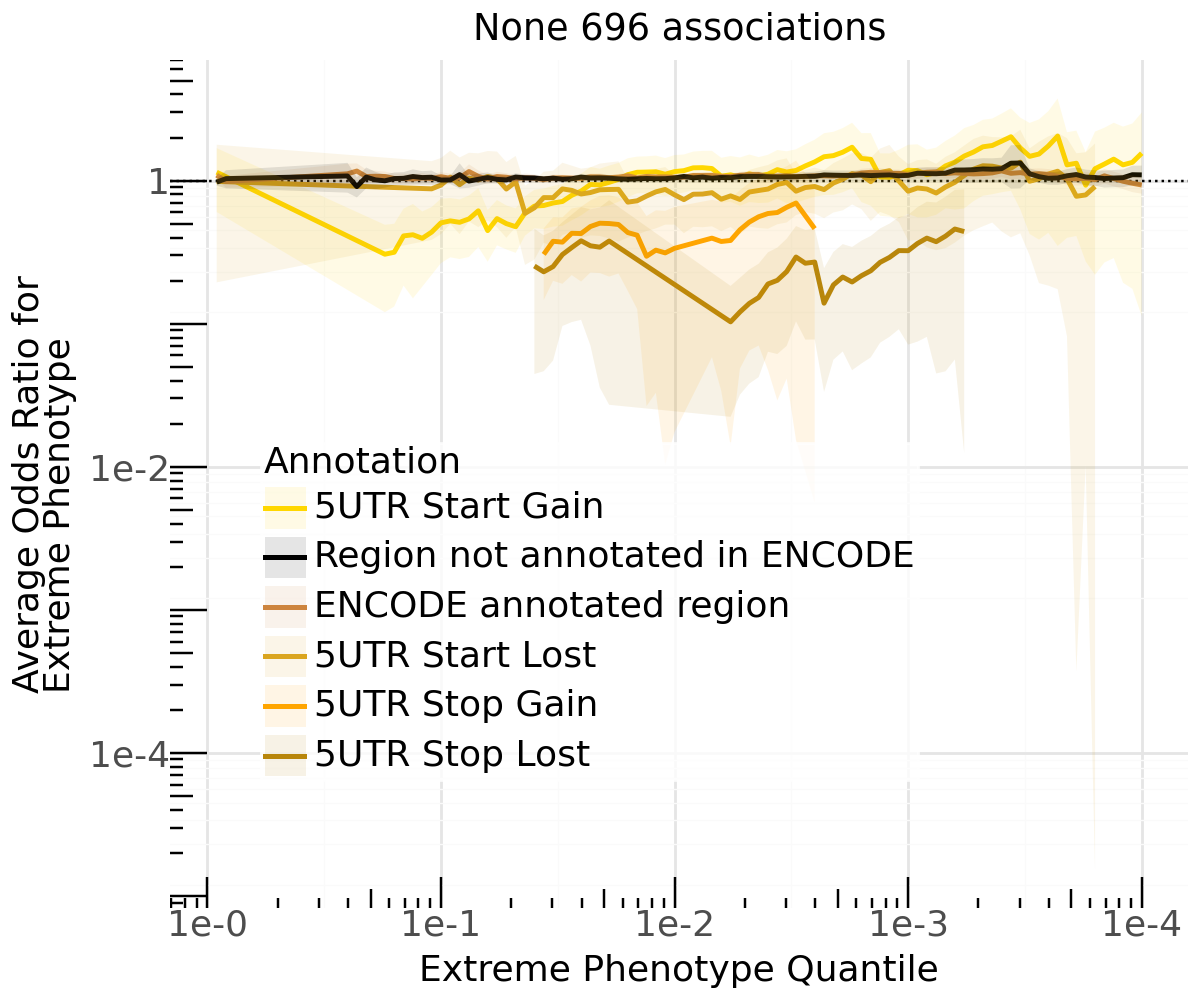

In [ ]:
# Determine legend order based on final average odds ratio
legend_order = (
    plt_df.sort("neg_log_pheno_cutoff_inv")
    .group_by("label", maintain_order=True)
    .last()
    .sort("avg_odds_ratio", descending=True)
    ['label']
    .to_list()
)

# Generate breaks and labels for x-axis
start_exp = int(-np.log10(or_threshold_pheno_left))
end_exp = int(-np.log10(or_threshold_pheno_right))
breaks_linear = np.arange(start_exp, end_exp + 1)
labels_sci = [f"1e-{b}" for b in breaks_linear]

color_dict = dict(zip(plt_df['label'], plt_df['color']))

(
    ggplot(
        plt_df,
        aes(x='neg_log_pheno_cutoff_inv', y='avg_odds_ratio')
    )
    + geom_hline(aes(yintercept=1), color='black', linetype='dotted')
    + geom_line(aes(color='label'), size=1)
    + geom_ribbon(aes(ymin='std_ci_lower', ymax='std_ci_upper', fill='label'), alpha=0.1)
    + scale_fill_manual(values=color_dict, limits=legend_order)
    + scale_color_manual(values=color_dict, limits=legend_order)
    + labs(
        title=f"{or_df[['gene_name', 'phenotype']].unique().shape[0]} associations - UTR variants",
        y=f"Average Odds Ratio for\nExtreme Phenotype",
        x="Extreme Phenotype Quantile",
        color="Annotation",
        fill="Annotation",
    )
    + scale_x_continuous(
        breaks=breaks_linear,
        labels=labels_sci
    )
    + scale_y_log10()
    + annotation_logticks(sides="lb")
    + theme_minimal()
    + theme(
        figure_size=(6, 5),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13, lineheight=1.4),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        legend_position=(0.25, 0.25), 
        legend_background=element_rect(fill="white", color='white', alpha=0.8),
        plot_background=element_rect(fill="white", color="white"),
    )
)

In [23]:
plt_df.filter(
    # (pl.col('annotation')=='five_prime_utr_variant_consequence_uaug_gained') &
    (pl.col('pheno_cutoff')==0.99)
    # (pl.col('annotation').is_in(['loftee_hc']))
)

annotation,neg_log_pheno_cutoff_inv,pheno_cutoff,pheno_cutoff_inv,n_gene_phenos,med_odds_ratio,avg_odds_ratio,se_odds_ratio,std_ci_upper,std_ci_lower,color,label
str,f64,f64,f64,u64,f64,f64,f64,f64,f64,str,str
"""not_annotated_in_encode""",2.0,0.99,0.01,274,1.003122,1.043646,0.023234,1.089184,0.998107,"""black""","""Region not annotated in ENCODE"""
"""five_prime_utr_variant_consequ…",2.0,0.99,0.01,40,0.0,0.336345,0.162703,0.655242,0.017448,"""#FFA500""","""5UTR Stop Gain"""
"""five_prime_utr_variant_consequ…",2.0,0.99,0.01,166,0.0,1.156183,0.180272,1.509515,0.802851,"""#FFD700""","""5UTR Start Gain"""
"""encode_annotated""",2.0,0.99,0.01,274,0.994534,1.054543,0.022309,1.098269,1.010816,"""peru""","""ENCODE annotated region"""
"""five_prime_utr_variant_consequ…",2.0,0.99,0.01,105,0.0,0.795877,0.154423,1.098545,0.493208,"""#DAA520""","""5UTR Start Lost"""


In [24]:
melted_anno.filter(
    # (pl.col('annotation')=='canonical_splice_variant') &
    (pl.col('annotation').str.contains('five_prime_utr_variant_consequence_uaug_gained')) &
    (pl.col('annotation_score_dircor')==1)
)

id,region,gene_name,annotation,annotation_score,category,annotation_dir,annotation_score_dircor
str,str,str,str,f32,str,i8,f32
"""chr15:98648571:G:T""","""ENSG00000140443""","""IGF1R""","""five_prime_utr_variant_consequ…",1.0,"""5utr_annotator""",1,1.0
"""chr2:233729089:G:A""","""ENSG00000288702""","""UGT1A3""","""five_prime_utr_variant_consequ…",1.0,"""5utr_annotator""",1,1.0
"""chr15:48178272:C:A""","""ENSG00000233932""","""CTXN2""","""five_prime_utr_variant_consequ…",1.0,"""5utr_annotator""",1,1.0
"""chr6:32115064:C:T""","""ENSG00000168477""","""TNXB""","""five_prime_utr_variant_consequ…",1.0,"""5utr_annotator""",1,1.0
"""chr14:31207604:G:T""","""ENSG00000092148""","""HECTD1""","""five_prime_utr_variant_consequ…",1.0,"""5utr_annotator""",1,1.0
…,…,…,…,…,…,…,…
"""chr10:128126119:A:T""","""ENSG00000148773""","""MKI67""","""five_prime_utr_variant_consequ…",1.0,"""5utr_annotator""",1,1.0
"""chr19:17101670:C:T""","""ENSG00000099331""","""MYO9B""","""five_prime_utr_variant_consequ…",1.0,"""5utr_annotator""",1,1.0
"""chr4:112818118:G:T""","""ENSG00000145362""","""ANK2""","""five_prime_utr_variant_consequ…",1.0,"""5utr_annotator""",1,1.0
